# Logistic Regression for Fake Review Detection

## 1. Introduction
This notebook implements an optimized **Logistic Regression** model to classify reviews as either **Real** (Original Reviews) or **Fake** (Computer-Generated). 

---


## 2. Environment Setup & Data Loading

We start by importing necessary libraries, setting a seed for reproducibility, and defining paths for data and model persistence. We load the precomputed TF-IDF features and split them into training (80%) and testing (20%) sets.


In [14]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Constants
RANDOM_STATE = 42
DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
FIGURES_DIR = "../figures"

# Create directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Set theme for plots
sns.set_theme(style="whitegrid")

print("Loading TF-IDF features and labels...")
X = joblib.load(os.path.join(DATA_DIR, "X_tfidf.pkl"))
y = joblib.load(os.path.join(DATA_DIR, "y.pkl"))
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")


Loading TF-IDF features and labels...
Features shape: (40432, 15000)
Labels shape: (40432,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Data split successfully:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Data split successfully:
Training samples: 32345
Testing samples: 8087


## 3. Hyperparameter Tuning

We use `GridSearchCV` to explore a range of regularization strengths (`C`) and solvers to find the optimal configuration for this dataset.


In [16]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

print("Starting Hyperparameter Tuning...")
grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")


Starting Hyperparameter Tuning...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV Score: 0.9058


## 4. Model Evaluation

We evaluate the optimized model on the unseen test set using accuracy and a detailed classification report.


In [10]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Real (OR)", "Fake (CG)"]))


Test Accuracy: 0.9106

Classification Report:

              precision    recall  f1-score   support

   Real (OR)       0.91      0.91      0.91      4044
   Fake (CG)       0.91      0.91      0.91      4043

    accuracy                           0.91      8087
   macro avg       0.91      0.91      0.91      8087
weighted avg       0.91      0.91      0.91      8087



## 5. Visualizing Results

We visualize the model performance using a Confusion Matrix, an ROC Curve, and by inspecting the top predictor features.


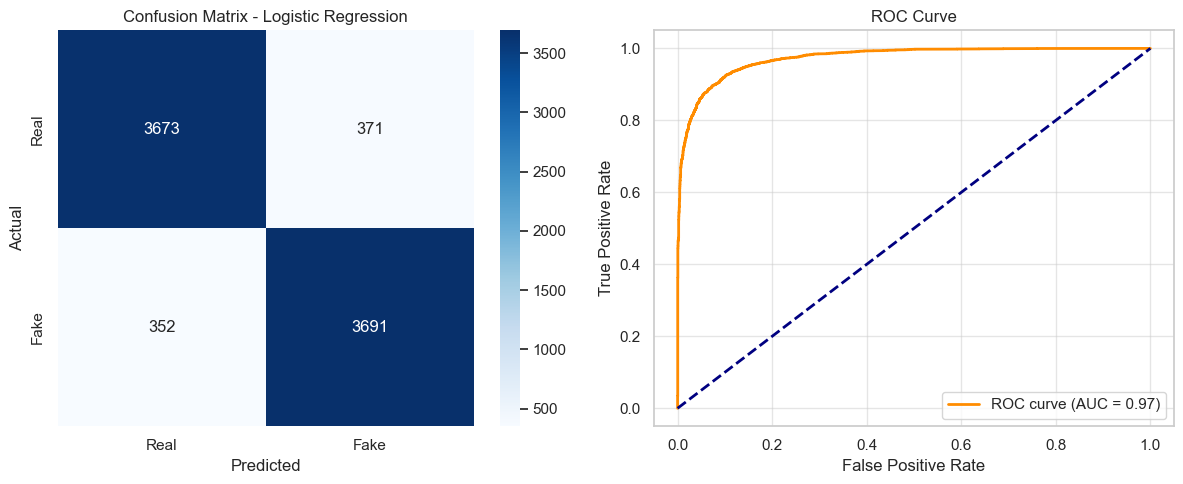

In [17]:
# 5.1. Confusion Matrix & ROC Curve
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

# ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "logreg_evaluation.png"))
plt.show()


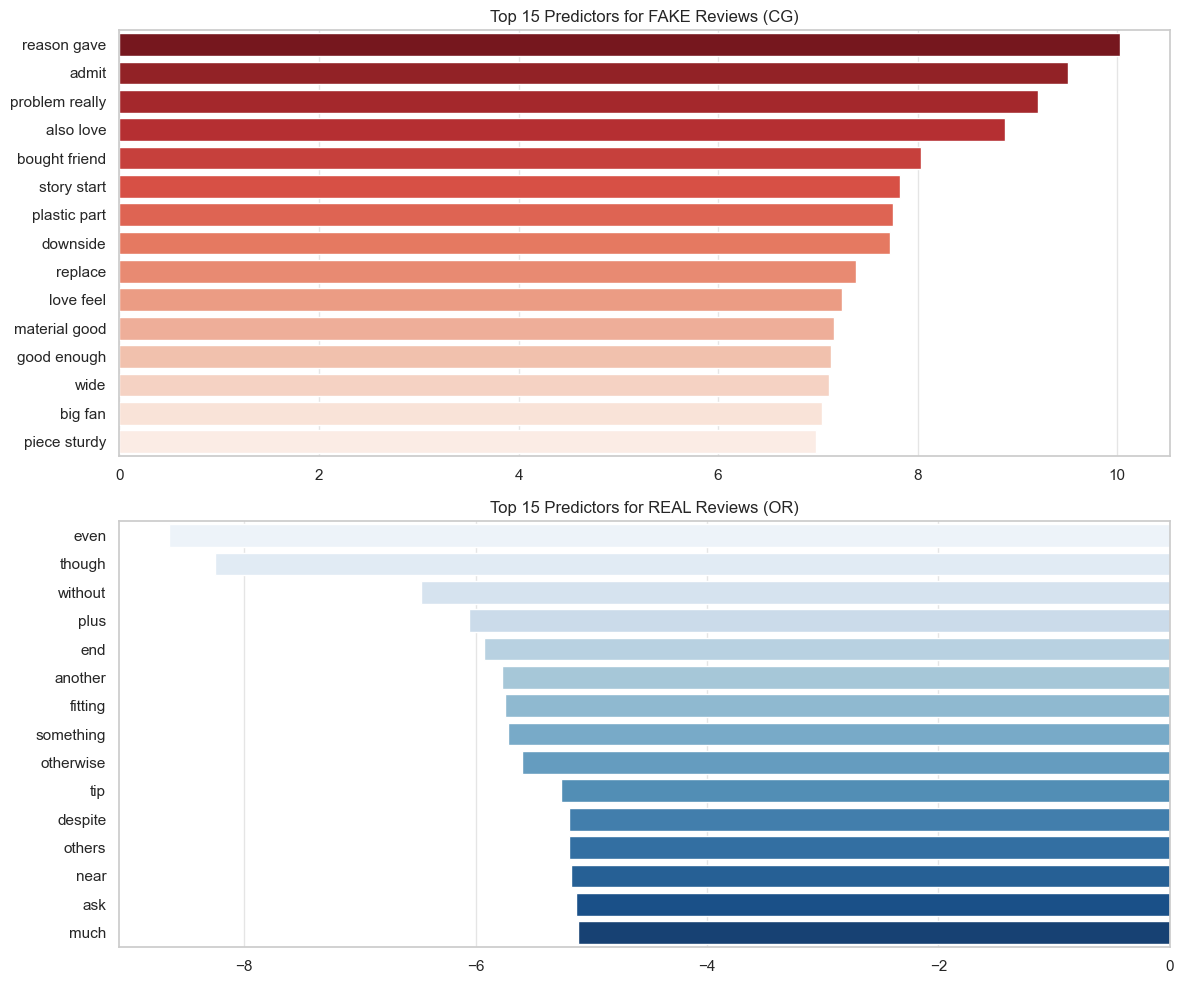

In [18]:
# 5.2. Top Features Analysis
vectorizer_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
if os.path.exists(vectorizer_path):
    vectorizer = joblib.load(vectorizer_path)
    feature_names = vectorizer.get_feature_names_out()
    coef = best_model.coef_[0]

    top_fake_idx = np.argsort(coef)[-15:][::-1]
    top_real_idx = np.argsort(coef)[:15]

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 1, 1)
    sns.barplot(x=coef[top_fake_idx], y=feature_names[top_fake_idx], palette='Reds_r', hue=feature_names[top_fake_idx], legend=False)
    plt.title("Top 15 Predictors for FAKE Reviews (CG)")
    
    plt.subplot(2, 1, 2)
    sns.barplot(x=coef[top_real_idx], y=feature_names[top_real_idx], palette='Blues', hue=feature_names[top_real_idx], legend=False)
    plt.title("Top 15 Predictors for REAL Reviews (OR)")

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "logreg_features.png"))
    plt.show()


## 6. Model Persistence

Finally, we save the trained model for future inference.


In [19]:
model_path = os.path.join(MODELS_DIR, "logreg_model.pkl")
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")


Model saved to: ../models\logreg_model.pkl
